<a href="https://colab.research.google.com/github/vedanttshah/Complete-Python-3-Bootcamp/blob/master/Algo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Environment Setup**

In [ ]:
# Cell 1: Environment setup with compatible pins (Colab)

# Upgrade pip so wheels resolve cleanly
!pip -q install --upgrade pip

# Pin NumPy to a version compatible with TF 2.19, numba 0.60, and OpenCV 4.12
# Pin pandas to a stable recent release; install remaining libs used in the notebook
!pip -q install \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "matplotlib>=3.8.0" \
  "yfinance>=0.2.40" \
  "ta==0.11.0" \
  "pandas_market_calendars==4.4.2"

# Quick sanity check: print versions
import numpy as np, pandas as pd, matplotlib
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# IMPORTANT: If you ran a previous cell with a different NumPy, go to:
# Runtime -> Restart runtime
# Then run from Cell 2 onward.


NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0


**Imports and Configurations**

In [ ]:
# Cell 2: Imports, configuration, and reusable utilities

import os
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal
from ta.volatility import AverageTrueRange
from ta.momentum import RSIIndicator

# Display options for readability in Colab
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

# Reproducibility
np.random.seed(42)

# ---- Time/market assumptions ----
# We'll treat daily bars as 252 trading days per year, which is standard for equities.
TRADING_DAYS = 252

def annualize_return(daily_ret: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    """
    Convert a series of daily returns to annualized geometric returns.
    """
    daily_ret = daily_ret.fillna(0.0)
    total = (1 + daily_ret).prod()
    years = len(daily_ret) / trading_days
    return total**(1/years) - 1 if years > 0 else np.nan

def annualize_vol(daily_ret: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    """Annualized volatility using daily stdev."""
    return daily_ret.std(ddof=0) * np.sqrt(trading_days)

def sharpe(daily_ret: pd.Series, rf: float = 0.0, trading_days: int = TRADING_DAYS) -> float:
    """
    Annualized Sharpe using daily returns and a constant risk-free rate (annual).
    """
    ex = daily_ret - rf / trading_days
    vol = annualize_vol(ex, trading_days)
    return np.nan if vol == 0 else annualize_return(ex, trading_days) / vol

def sortino(daily_ret: pd.Series, rf: float = 0.0, trading_days: int = TRADING_DAYS) -> float:
    """Annualized Sortino ratio using downside deviation."""
    ex = daily_ret - rf / trading_days
    downside = ex[ex < 0].std(ddof=0) * np.sqrt(trading_days)
    return np.nan if downside == 0 else annualize_return(ex, trading_days) / downside

def max_drawdown(cum_curve: pd.Series) -> float:
    """
    Max drawdown from cumulative return curve (e.g., equity curve).
    Returns a negative number (e.g., -0.32 for -32%).
    """
    roll_max = cum_curve.cummax()
    dd = cum_curve / roll_max - 1.0
    return dd.min()

def calmar(daily_ret: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    """Calmar = CAGR / |MaxDD|."""
    eq = (1 + daily_ret.fillna(0)).cumprod()
    mdd = abs(max_drawdown(eq))
    return np.nan if mdd == 0 else annualize_return(daily_ret, trading_days) / mdd

def win_rate(daily_ret: pd.Series) -> float:
    """Fraction of positive-return days."""
    r = daily_ret.dropna()
    return (r > 0).mean()

def profit_factor(daily_ret: pd.Series) -> float:
    """Sum(gains) / Sum(losses)."""
    gains = daily_ret[daily_ret > 0].sum()
    losses = -daily_ret[daily_ret < 0].sum()
    return np.nan if losses == 0 else gains / losses

def plot_equity_curve(daily_ret: pd.Series, title: str = "Equity Curve") -> None:
    """
    Plot cumulative return (1 + r).cumprod() using Matplotlib.
    """
    eq = (1 + daily_ret.fillna(0)).cumprod()
    plt.figure(figsize=(10,4))
    eq.plot()
    plt.title(title)
    plt.grid(True)
    plt.show()

def summarize_perf(daily_ret: pd.Series, name: str = "Strategy") -> pd.Series:
    """
    Nicely formatted performance summary for display/CSV.
    """
    eq = (1 + daily_ret.fillna(0)).cumprod()
    summary = {
        "Name": name,
        "CAGR": f"{annualize_return(daily_ret)*100:.2f}%",
        "Ann.Vol": f"{annualize_vol(daily_ret)*100:.2f}%",
        "Sharpe": f"{sharpe(daily_ret):.2f}",
        "Sortino": f"{sortino(daily_ret):.2f}",
        "MaxDD": f"{max_drawdown(eq)*100:.2f}%",
        "Calmar": f"{calmar(daily_ret):.2f}",
        "WinRate": f"{win_rate(daily_ret)*100:.2f}%",
        "ProfitFactor": f"{profit_factor(daily_ret):.2f}",
        "N Days": len(daily_ret)
    }
    return pd.Series(summary)


**Universe & Strategy Parameters**

In [ ]:
# Cell 3: Universe and hyperparameters

# Liquid large-cap Indian equities (Yahoo Finance uses the .NS suffix)
UNIVERSE = [
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
    "HINDUNILVR.NS","KOTAKBANK.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
    "ITC.NS","ASIANPAINT.NS","MARUTI.NS","AXISBANK.NS","SUNPHARMA.NS"
]

# Backtest window (daily)
START_DATE = "2014-01-01"
END_DATE   = None       # None = today
INTERVAL   = "1d"

# Cross-sectional momentum (12-1): rank by 12M return excluding last month
MOM_LOOKBACK_DAYS = 252
SKIP_LAST_DAYS    = 21
TOP_N             = 8            # how many winners to hold long
REBAL_FREQ        = "M"          # rebalance at month-end
VOL_LOOKBACK      = 20           # inverse-vol weighting horizon (days)
TARGET_PORTF_VOL  = 0.15         # 15% annualized target portfolio vol
MAX_WEIGHT        = 0.20         # cap per asset to avoid concentration

# Frictions (very important in India)
COST_BPS          = 10           # commission/fees per side in basis points
SLIPPAGE_BPS      = 5            # extra slippage per side in bps (conservative)

# Risk-free (annualized), used only for metrics
RF_ANNUAL = 0.00


**OHLCV for equities**

In [ ]:
# Cell 4: Data download and cleaning (yfinance)

# Download multi-index DataFrame (ticker, field)
raw = yf.download(
    UNIVERSE, start=START_DATE, end=END_DATE,
    interval=INTERVAL, auto_adjust=True, progress=False, group_by='ticker'
)

def get_panel(raw_df):
    """
    Convert yfinance's multi-index columns into separate wide DataFrames:
    Close/High/Low/Volume, indexed by date, columns=tickers.
    """
    close = pd.DataFrame({t: raw_df[t]["Close"] for t in UNIVERSE}).tz_localize(None)
    high  = pd.DataFrame({t: raw_df[t]["High"]  for t in UNIVERSE}).tz_localize(None)
    low   = pd.DataFrame({t: raw_df[t]["Low"]   for t in UNIVERSE}).tz_localize(None)
    vol   = pd.DataFrame({t: raw_df[t]["Volume"]for t in UNIVERSE}).tz_localize(None)
    return close.sort_index(), high.sort_index(), low.sort_index(), vol.sort_index()

close, high, low, vol = get_panel(raw)

# Drop names without sufficient history for 12-1 momentum (lookback + skip + buffer)
min_start = close.index.min() + pd.Timedelta(days=MOM_LOOKBACK_DAYS + SKIP_LAST_DAYS + 10)
valid_cols = [c for c in close.columns
              if close[c].first_valid_index() is not None
              and close[c].first_valid_index() <= min_start]

close, high, low, vol = close[valid_cols], high[valid_cols], low[valid_cols], vol[valid_cols]
print(f"Downloaded {len(valid_cols)} tickers with sufficient history.")
close.tail()


Downloaded 15 tickers with sufficient history.


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,KOTAKBANK.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,ITC.NS,ASIANPAINT.NS,MARUTI.NS,AXISBANK.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,
2025-10-21,1465.199951,3006.699951,1007.700012,1450.199219,1382.000000,2591.699951,2197.000000,3888.199951,907.849976,2043.500000,412.850006,2504.600098,16396.0,1237.300049,1690.500000
2025-10-23,1448.400024,3073.199951,1008.799988,1505.453247,1363.699951,2601.600098,2225.600098,3918.699951,911.549988,2007.900024,415.950012,2502.399902,16393.0,1258.800049,1689.900024
2025-10-24,1451.599976,3063.199951,994.750000,1502.400024,1377.699951,2516.399902,2187.000000,3904.899902,904.500000,2029.300049,416.799988,2501.600098,16274.0,1241.900024,1699.000000
2025-10-27,1484.099976,3084.899902,1002.950012,1504.500000,1377.599976,2511.800049,2148.600098,3923.800049,922.750000,2080.100098,420.649994,2518.800049,16388.0,1254.099976,1693.599976
2025-10-28,1486.900024,3057.899902,1003.549988,1500.199951,1363.099976,2497.100098,2160.800049,3972.800049,930.250000,2090.199951,417.899994,2509.300049,16311.0,1246.300049,1687.000000


**Returns, momentum signal, and rebalance dates**

In [ ]:
# Cell 5 (fixed): Signals and rebalance schedule (month-end safe)

# Daily simple returns
ret = close.pct_change().replace([np.inf, -np.inf], np.nan)

# 12-1 momentum (skip last month to reduce short-term reversal contamination)
# mom_t = Close[t-21] / Close[t-(252+21)] - 1
mom = close.shift(SKIP_LAST_DAYS) / close.shift(MOM_LOOKBACK_DAYS + SKIP_LAST_DAYS) - 1.0

# Realized vol estimator for inverse-vol weighting (annualized)
vol_d = ret.rolling(VOL_LOOKBACK).std() * np.sqrt(TRADING_DAYS)

# --- Build month-end rebalance calendar safely ---
# 'M' is deprecated; use 'ME' for month-end
freq = "ME" if REBAL_FREQ in ("M", "ME") else REBAL_FREQ

# Month-end dates aligned to our trading calendar
rebal_dates = close.resample(freq).last().index

# Keep only dates actually present in price data
rebal_dates = rebal_dates.intersection(close.index)

# Keep only dates where momentum is available (row with at least one non-NaN mom value)
mom_valid_idx = mom.index[mom.notna().any(axis=1)]
rebal_dates = rebal_dates.intersection(mom_valid_idx)

# Defensive: ensure we have at least a few rebalances
if len(rebal_dates) < 3:
    raise ValueError(
        "Not enough valid rebalance dates. "
        "Check START_DATE, lookbacks (MOM_LOOKBACK_DAYS, SKIP_LAST_DAYS), "
        "and data availability."
    )

# Display a quick sanity check
print("Number of rebalances:", len(rebal_dates))
print("First 5 rebal dates:", rebal_dates[:5].strftime('%Y-%m-%d').tolist())

# Peek at momentum values on rebal dates
mom.loc[rebal_dates].tail()


Number of rebalances: 88
First 5 rebal dates: ['2015-03-31', '2015-04-30', '2015-06-30', '2015-07-31', '2015-08-31']


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,KOTAKBANK.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,ITC.NS,ASIANPAINT.NS,MARUTI.NS,AXISBANK.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,
2025-02-28,-0.053645,0.095288,0.201246,0.168447,0.230658,0.035768,0.066732,-0.029050,0.281422,0.424779,-0.019254,-0.255078,0.228478,-0.095286,0.272988
2025-04-30,-0.103757,-0.057804,0.263476,0.056728,0.243047,0.012029,0.227246,-0.008516,0.073241,0.423241,0.028248,-0.165341,0.021392,0.044058,0.146412
2025-06-30,-0.036837,-0.079375,0.281901,0.115827,0.288261,0.012545,0.219275,0.021537,0.000013,0.344288,0.009041,-0.205194,-0.043467,0.016286,0.138806
2025-07-31,-0.004309,-0.101700,0.183768,0.049833,0.180500,-0.042102,0.186243,0.018501,-0.017509,0.385439,0.003752,-0.150977,0.046185,-0.087469,0.116545
2025-09-30,-0.094067,-0.284718,0.176552,-0.190669,0.159447,-0.021101,0.092894,-0.019105,0.007765,0.258571,-0.161303,-0.179345,0.204149,-0.100608,-0.118197


**Portfolio construction (inverse-vol, top-N, vol targeting)**

In [ ]:
# Cell 6: Build target weights W (dates x tickers) using rebal_dates from Cell 5

def build_weights(mom_df, vol_df, rebal_idx, top_n=8, max_w=0.20, target_port_vol=0.15):
    """
    For each rebalance date:
    1) Rank by momentum, pick top_n
    2) Inverse-vol raw weights, cap per asset at max_w
    3) Scale vector to target portfolio vol (<= 1x leverage)
    4) Forward-fill until next rebalance
    """
    W = pd.DataFrame(0.0, index=mom_df.index, columns=mom_df.columns)

    for dt in rebal_idx:
        s = mom_df.loc[dt].dropna()
        v = vol_df.loc[dt].reindex(s.index).replace(0, np.nan).dropna()

        if len(v) == 0:
            continue

        winners = s.reindex(v.index).sort_values(ascending=False).head(top_n).index
        inv_vol = 1.0 / v.loc[winners]
        raw_w = inv_vol / inv_vol.sum()

        # Cap concentration
        capped_w = raw_w.clip(upper=max_w)
        capped_w = capped_w / capped_w.sum()

        # Approx portfolio vol (assume low corr → conservative)
        port_vol_est = np.sqrt((capped_w.values**2 * v.loc[capped_w.index].values**2).sum())

        # Scale to target portfolio volatility (keep leverage ≤ 1)
        scale = 1.0
        if np.isfinite(port_vol_est) and port_vol_est > 0:
            scale = min(1.0, target_port_vol / port_vol_est)

        W.loc[dt, capped_w.index] = capped_w.values * scale

    # Hold between rebalances
    W = W.loc[rebal_idx].reindex(mom_df.index).ffill().fillna(0.0)
    return W

W = build_weights(mom, vol_d, rebal_dates,
                  top_n=TOP_N, max_w=MAX_WEIGHT, target_port_vol=TARGET_PORTF_VOL)
W.tail()


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,KOTAKBANK.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,ITC.NS,ASIANPAINT.NS,MARUTI.NS,AXISBANK.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,
2025-10-21,0.0,0.0,0.184069,0.0,0.170146,0.122607,0.109425,0.101634,0.101843,0.129005,0.0,0.0,0.08127,0.0,0.0
2025-10-23,0.0,0.0,0.184069,0.0,0.170146,0.122607,0.109425,0.101634,0.101843,0.129005,0.0,0.0,0.08127,0.0,0.0
2025-10-24,0.0,0.0,0.184069,0.0,0.170146,0.122607,0.109425,0.101634,0.101843,0.129005,0.0,0.0,0.08127,0.0,0.0
2025-10-27,0.0,0.0,0.184069,0.0,0.170146,0.122607,0.109425,0.101634,0.101843,0.129005,0.0,0.0,0.08127,0.0,0.0
2025-10-28,0.0,0.0,0.184069,0.0,0.170146,0.122607,0.109425,0.101634,0.101843,0.129005,0.0,0.0,0.08127,0.0,0.0


**Backtest with transaction costs & slippage**

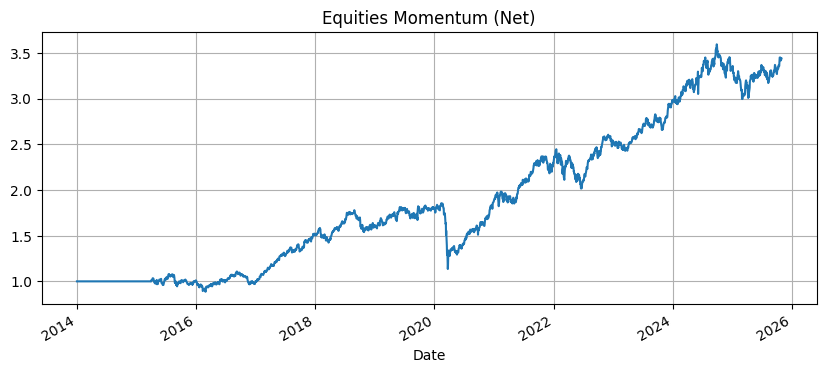

,Value
Name,EQ X-Section Momentum (Net)
CAGR,11.26%
Ann.Vol,15.12%
Sharpe,0.74
Sortino,0.84
MaxDD,-38.78%
Calmar,0.29
WinRate,48.11%
ProfitFactor,1.16
N Days,2916


In [ ]:
# Cell 7: Backtest with frictions applied on rebalance dates

# Roundtrip cost rate proxy (bps per side + slippage per side)
COST_RATE = (COST_BPS + SLIPPAGE_BPS) / 10000.0

# Avoid lookahead: yesterday's weights on today's returns
port_ret_gross = (W.shift(1) * ret).sum(axis=1)

# Turnover computed only on rebalance dates
W_prev = W.shift(1).fillna(0.0)
turnover = (W.loc[rebal_dates] - W_prev.loc[rebal_dates]).abs().sum(axis=1)

# Map turnover to costs on those dates
cost_series = pd.Series(0.0, index=port_ret_gross.index)
cost_series.loc[rebal_dates] = turnover * COST_RATE

# Net daily returns
port_ret_net = port_ret_gross - cost_series

# Plot & summary
plot_equity_curve(port_ret_net, "Equities Momentum (Net)")
summary_eq = summarize_perf(port_ret_net, "EQ X-Section Momentum (Net)")
summary_eq.to_frame(name="Value")


**Baselines (equal-weight basket and single-name buy-and-hold)**

In [ ]:
# Cell 8: Baseline comparisons

# Equal-weight basket (monthly ME rebalance) on the names active at first rebalance
first_reb = rebal_dates[0]
base_names = W.columns[(W.loc[first_reb] > 0).values]
EW = pd.DataFrame(0.0, index=W.index, columns=W.columns)
if len(base_names) > 0:
    EW.loc[rebal_dates, base_names] = 1.0 / len(base_names)
EW = EW.loc[rebal_dates].reindex(W.index).ffill().fillna(0.0)

ew_ret = (EW.shift(1) * ret).sum(axis=1)
ew_turnover = (EW.loc[rebal_dates] - EW.shift(1).loc[rebal_dates]).abs().sum(axis=1)
ew_costs = pd.Series(0.0, index=ew_ret.index); ew_costs.loc[rebal_dates] = ew_turnover * COST_RATE
ew_ret_net = ew_ret - ew_costs

# Simple buy & hold for reference
bh_ret = ret["RELIANCE.NS"].fillna(0.0)

summary_ew = summarize_perf(ew_ret_net, "Equal-Weight Basket (Net)")
summary_bh = summarize_perf(bh_ret, "Buy&Hold RELIANCE")

pd.concat([summary_eq, summary_ew, summary_bh], axis=1)


,0,1,2
Name,EQ X-Section Momentum (Net),Equal-Weight Basket (Net),Buy&Hold RELIANCE
CAGR,11.26%,14.24%,19.55%
Ann.Vol,15.12%,18.81%,26.99%
Sharpe,0.74,0.76,0.72
Sortino,0.84,0.89,1.09
MaxDD,-38.78%,-42.05%,-45.09%
Calmar,0.29,0.34,0.43
WinRate,48.11%,48.59%,51.78%
ProfitFactor,1.16,1.17,1.15
N Days,2916,2916,2916


**Walk-forward validation (time splits)**

In [ ]:
# Cell 9: 3-fold time-based splits to assess stability

def time_slices(index, k=3):
    n = len(index)
    splits = []
    for i in range(k):
        lo = int(i * n / k)
        hi = int((i+1) * n / k)
        splits.append((index[lo], index[hi-1]))
    return splits

def slice_perf(r, label_prefix):
    res = {}
    idx = r.index
    for i, (lo, hi) in enumerate(time_slices(idx, k=3), 1):
        s = r.loc[lo:hi]
        res[f"{label_prefix} Fold{i}"] = summarize_perf(s, f"{label_prefix} Fold{i}")
    return pd.DataFrame(res)

wf_eq = slice_perf(port_ret_net, "EQ")
wf_eq


,EQ Fold1,EQ Fold2,EQ Fold3
Name,EQ Fold1,EQ Fold2,EQ Fold3
CAGR,10.55%,12.21%,11.04%
Ann.Vol,11.89%,18.78%,13.86%
Sharpe,0.89,0.65,0.80
Sortino,1.03,0.70,1.07
MaxDD,-17.55%,-38.78%,-17.59%
Calmar,0.60,0.31,0.63
WinRate,35.70%,55.45%,53.19%
ProfitFactor,1.20,1.15,1.15
N Days,972,972,972


**Load NIFTY index as a futures proxy (Yahoo)**

In [ ]:
# Cell 10 (updated): Load NIFTY index (^NSEI) as a proxy and compute ATR/RSI manually

import yfinance as yf
import pandas as pd
import numpy as np

def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, window: int = 20) -> pd.Series:
    """
    Wilder's ATR:
      TR_t = max(High_t - Low_t, |High_t - Close_{t-1}|, |Low_t - Close_{t-1}|)
      ATR  = EMA(TR, window)  [Wilder's smoothing]. For simplicity, we use SMA here.
    """
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    atr = tr.rolling(window).mean()
    return atr

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """
    Classic RSI using Wilder's smoothing (approx via EMA).
    """
    delta = close.diff()
    up = delta.clip(lower=0.0)
    down = (-delta).clip(lower=0.0)
    # Wilder's smoothing approximation with EMA(alpha=1/window)
    roll_up = up.ewm(alpha=1/window, adjust=False).mean()
    roll_down = down.ewm(alpha=1/window, adjust=False).mean()
    rs = roll_up / roll_down.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Download daily OHLCV for NIFTY index
idx = yf.download("^NSEI", start=START_DATE, end=END_DATE,
                  interval="1d", auto_adjust=False, progress=False)

# Defensive checks & cleaning
if idx.empty:
    raise ValueError("Yahoo returned empty data for ^NSEI. Try changing START_DATE/END_DATE or retry later.")

# Keep the needed columns; drop rows with missing values
needed_cols = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed_cols if c not in idx.columns]
if missing:
    raise ValueError(f"^NSEI download missing columns: {missing}")

fut = idx[needed_cols].copy()
fut = fut.dropna().sort_index()
fut = fut[~fut.index.duplicated(keep="first")]

# Indicators for the breakout model (manual implementations)
atr = compute_atr(fut["High"], fut["Low"], fut["Close"], window=20)
rsi = compute_rsi(fut["Close"], window=14)

print("Loaded ^NSEI (index) as futures proxy.")
print("Rows:", len(fut), "| Date range:", fut.index.min().date(), "→", fut.index.max().date())
fut.tail()


Loaded ^NSEI (index) as futures proxy.
Rows: 2904 | Date range: 2014-01-02 → 2025-10-28


Price,Open,High,Low,Close,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2025-10-21,25901.199219,25934.349609,25825.800781,25868.599609,42500
2025-10-23,26057.199219,26104.199219,25862.449219,25891.400391,448400
2025-10-24,25935.099609,25944.150391,25718.199219,25795.150391,284900
2025-10-27,25843.199219,26005.949219,25827.000000,25966.050781,266300
2025-10-28,25939.949219,26041.699219,25810.050781,25936.199219,0


**Donchian breakout + ATR stop (using manual ATR/RSI)**

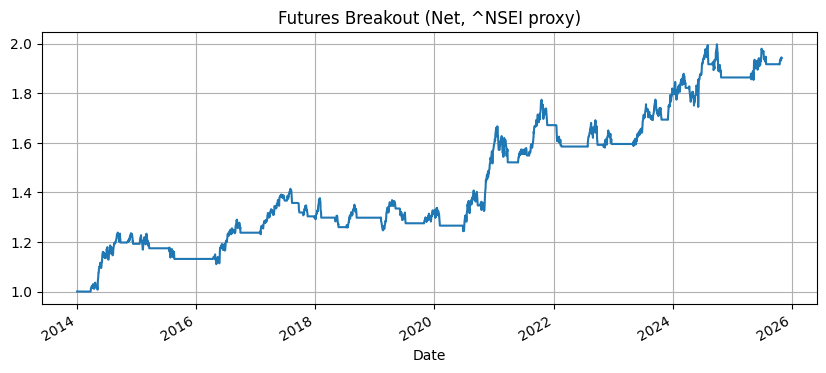

,Value
Name,"FUT Breakout (Net, proxy)"
CAGR,5.93%
Ann.Vol,8.77%
Sharpe,0.68
Sortino,0.67
MaxDD,-12.10%
Calmar,0.49
WinRate,27.86%
ProfitFactor,1.18
N Days,2904


In [ ]:
# Cell 11 (robust): Donchian breakout with ATR stop (long/flat) on ^NSEI proxy
# Assumes Cell 10 created: fut (OHLCV DataFrame), atr (Series), and you have START_DATE/END_DATE

import numpy as np
import pandas as pd

DONCHIAN_ENTRY = 55   # enter long when Close > prior-day 55D high
DONCHIAN_EXIT  = 20   # exit to flat when Close < prior-day 20D low
ATR_MULT_STOP  = 3.0  # protective stop distance in ATRs
LEVERAGE       = 1.0  # 1.0 = 100% notional exposure
FEE_BPS        = 2    # commission per side (bps)
SLIP_BPS       = 2    # slippage per side (bps)
TOTAL_BPS      = (FEE_BPS + SLIP_BPS) / 10000.0

# --- Helper: ensure 1-D Series aligned to a given index ---
def to_series(obj, index):
    """
    Convert Series/DataFrame/ndarray to a 1-D float Series aligned to 'index'.
    If it's a DataFrame with 1 column, use that column; with >1 columns, take row-wise mean.
    """
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] == 1:
            obj = obj.iloc[:, 0]
        else:
            obj = obj.mean(axis=1)
    elif isinstance(obj, np.ndarray):
        obj = pd.Series(obj.ravel(), index=index)
    elif isinstance(obj, pd.Series):
        obj = obj.copy()
    else:
        obj = pd.Series(obj, index=index)
    return obj.reindex(index).astype(float)

# --- Build bands and signals as 1-D Series ---
price = to_series(fut["Close"], fut.index)

highN = to_series(fut["High"], fut.index).rolling(DONCHIAN_ENTRY).max()
lowM  = to_series(fut["Low"],  fut.index).rolling(DONCHIAN_EXIT).min()

highN_prev = to_series(highN.shift(1), fut.index)
lowM_prev  = to_series(lowM.shift(1),  fut.index)

# Comparisons yield 1-D boolean Series; cast to int (0/1)
signal_long = (price > highN_prev).astype(int)
signal_flat = (price < lowM_prev).astype(int)

# Warm-up: need both bands available
valid_mask = (~highN_prev.isna()) & (~lowM_prev.isna())
if not valid_mask.any():
    raise ValueError("Donchian bands never become valid. Increase history or lower DONCHIAN_ENTRY/EXIT.")
first_valid_pos = int(np.argmax(valid_mask.values))

# --- Position state machine (1=long, 0=flat) ---
pos = pd.Series(0.0, index=price.index, dtype=float)
for i in range(first_valid_pos + 1, len(price)):
    if (pos.iat[i-1] == 0.0) and (signal_long.iat[i] == 1):
        pos.iat[i] = 1.0
    elif (pos.iat[i-1] == 1.0) and (signal_flat.iat[i] == 1):
        pos.iat[i] = 0.0
    else:
        pos.iat[i] = pos.iat[i-1]

# --- ATR stop: if today's close < entry_price - k*ATR → flat from today ---
atr_aligned = to_series(atr, price.index).fillna(0.0)  # 0 during warm-up to avoid spurious stops
entry_price = pd.Series(np.nan, index=price.index, dtype=float)
for i in range(first_valid_pos + 1, len(price)):
    if (pos.iat[i-1] == 0.0) and (pos.iat[i] == 1.0):
        entry_price.iat[i] = price.iat[i]
    else:
        entry_price.iat[i] = entry_price.iat[i-1]

stop_level = entry_price - ATR_MULT_STOP * atr_aligned
stop_hit = (pos.shift(1) == 1.0) & (price < stop_level)
pos = pos.where(~stop_hit, other=0.0)

# --- P&L with 1-bar lag on exposure ---
ret_fut = price.pct_change().fillna(0.0)
gross = LEVERAGE * pos.shift(1).fillna(0.0) * ret_fut

# Transaction costs on transitions (enter or exit)
pos_chg = (pos - pos.shift(1)).abs().fillna(0.0)  # 1.0 on each transition
costs = pos_chg * TOTAL_BPS

net = gross - costs

# Plot & summarize (reuses helpers from earlier cells)
plot_equity_curve(net, "Futures Breakout (Net, ^NSEI proxy)")
summary_fut = summarize_perf(net, "FUT Breakout (Net, proxy)")
summary_fut.to_frame(name="Value")


**Compare strategies (equities vs proxy futures) + optional combined plot**

,0,1
Name,EQ X-Section Momentum (Net),"FUT Breakout (Net, proxy)"
CAGR,11.26%,5.93%
Ann.Vol,15.12%,8.77%
Sharpe,0.74,0.68
Sortino,0.84,0.67
MaxDD,-38.78%,-12.10%
Calmar,0.29,0.49
WinRate,48.11%,27.86%
ProfitFactor,1.16,1.18
N Days,2916,2904


<Figure size 1000x400 with 0 Axes>

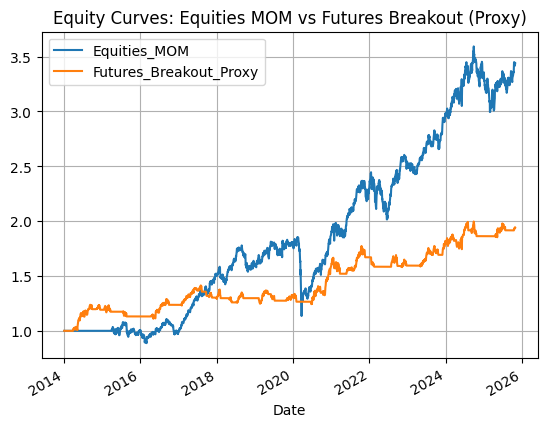

In [ ]:
# Cell 12: Side-by-side summary (equities vs futures proxy) and optional combined equity plot

# Ensure the required objects exist
assert 'summary_eq' in globals(), "summary_eq not found. Run Cells 6–8 first."
assert 'summary_fut' in globals(), "summary_fut not found. Run Cell 11 first."
assert 'port_ret_net' in globals(), "port_ret_net not found. Run Cells 6–7 first."
assert 'net' in globals(), "net (futures returns) not found. Run Cell 11 first."

# Comparison table
summary = pd.concat([summary_eq, summary_fut], axis=1)
display(summary)

# Optional: combined equity curve for quick visual comparison
eq_equity = (1 + port_ret_net.fillna(0)).cumprod().rename("Equities_MOM")
fut_equity = (1 + net.fillna(0)).cumprod().rename("Futures_Breakout_Proxy")

combined = pd.concat([eq_equity, fut_equity], axis=1).dropna()
plt.figure(figsize=(10,4))
combined.plot()
plt.title("Equity Curves: Equities MOM vs Futures Breakout (Proxy)")
plt.grid(True)
plt.show()


**Export artifacts (CSV)**

In [ ]:
# Cell 13: Persist outputs for review/production (CSV files in current working dir)

# Equities momentum artifacts
(1 + port_ret_net).cumprod().to_csv("equity_curve_equities_mom.csv")
W.to_csv("weights_equities_mom.csv")
port_ret_net.to_csv("daily_returns_equities_mom.csv")

# Futures proxy breakout artifacts
(1 + net).cumprod().to_csv("equity_curve_futures_breakout_proxy.csv")
net.to_csv("daily_returns_futures_breakout_proxy.csv")

print("Saved:")
print(" - equity_curve_equities_mom.csv")
print(" - weights_equities_mom.csv")
print(" - daily_returns_equities_mom.csv")
print(" - equity_curve_futures_breakout_proxy.csv")
print(" - daily_returns_futures_breakout_proxy.csv")


Saved:
 - equity_curve_equities_mom.csv
 - weights_equities_mom.csv
 - daily_returns_equities_mom.csv
 - equity_curve_futures_breakout_proxy.csv
 - daily_returns_futures_breakout_proxy.csv


**(Optional) — Simple parameter sweep (train/test) on equities**

In [ ]:
# Cell 14 (Optional): Sweep TOP_N and VOL_LOOKBACK; evaluate on 70/30 split

assert 'ret' in globals() and 'mom' in globals() and 'rebal_dates' in globals(), \
    "Missing inputs for sweep. Run Cells 4–7 first."

split = int(len(port_ret_net)*0.7)
train_idx, test_idx = ret.index[:split], ret.index[split:]

def run_eq(top_n, vol_lb):
    """
    Recompute weights and net returns for given hyperparameters.
    """
    vol_tmp = ret.rolling(vol_lb).std() * np.sqrt(TRADING_DAYS)
    W_tmp = build_weights(mom, vol_tmp, rebal_dates, top_n=top_n,
                          max_w=MAX_WEIGHT, target_port_vol=TARGET_PORTF_VOL)
    pr = (W_tmp.shift(1) * ret).sum(axis=1)
    turnover = (W_tmp.loc[rebal_dates] - W_tmp.shift(1).loc[rebal_dates]).abs().sum(axis=1)
    costs = pd.Series(0.0, index=pr.index); costs.loc[rebal_dates] = turnover * ((COST_BPS + SLIPPAGE_BPS) / 10000.0)
    net_ = pr - costs
    return net_

grid = []
for tn in [5, 8, 10, 12]:
    for vl in [15, 20, 30]:
        net_ = run_eq(tn, vl)
        tr, te = net_.loc[train_idx], net_.loc[test_idx]
        grid.append((tn, vl, sharpe(tr), sharpe(te)))

grid_df = pd.DataFrame(grid, columns=["TOP_N","VOL_LB","Sharpe_Train","Sharpe_Test"])\
           .sort_values(["Sharpe_Test","Sharpe_Train"], ascending=False)

display(grid_df.head(10))


,TOP_N,VOL_LB,Sharpe_Train,Sharpe_Test
2,5,30,0.726116,1.280707
1,5,20,0.727665,1.266478
0,5,15,0.737458,1.208519
11,12,30,0.890957,1.128550
10,12,20,0.880341,1.120465
9,12,15,0.863728,1.086280
8,10,30,0.786007,0.999325
7,10,20,0.775938,0.991149
6,10,15,0.759209,0.958826
5,8,30,0.707260,0.929621


**Kite Connect and imports**

In [ ]:
# Cell 15: Install and import Kite Connect SDK
!pip -q install kiteconnect

from kiteconnect import KiteConnect, KiteTicker
import time
import math


ACCESS CODE GENERATION

In [ ]:
import os
from kiteconnect import KiteConnect
from dotenv import load_dotenv

# Load API key and secret
load_dotenv()
api_key = ("gstesnsbvj6o0syx")
api_secret = ("7p3lq2w5cl5fqggd0mxxlwqqln5p7xaw")

kite = KiteConnect(api_key=api_key)
print("Login URL:", kite.login_url())


Login URL: https://kite.zerodha.com/connect/login?api_key=gstesnsbvj6o0syx&v=3


**Kite initialization (authentication)**

In [ ]:
# Cell 16 (fixed): Initialize KiteConnect with proper login flow
from kiteconnect import KiteConnect
import os

# STEP 1: Get your API key and secret
# It's recommended to store these securely (e.g., in environment variables or a secrets manager)
# For this example, we'll use variables, but avoid hardcoding in production code.
# Replace with your actual API key and secret
api_key = "gstesnsbvj6o0syx"
api_secret = "7p3lq2w5cl5fqggd0mxxlwqqln5p7xaw"


# Initialize Kite
kite = KiteConnect(api_key=api_key)

# STEP 2: generate login URL — open this in your browser, log in, and copy the 'request_token' from the redirect URL.
print("Login URL (open this in browser):", kite.login_url())

# After login, you’ll get redirected to your redirect URL like:
# https://example.com/?request_token=abcd1234xyz&status=success
# Copy only that request_token part.

# STEP 3: Exchange the request_token for an access_token using your API secret
# You will be prompted to enter the request_token here after logging in via the URL above.
request_token = input("Paste the request_token here: ")

try:
    data = kite.generate_session(request_token, api_secret=api_secret)
    access_token = data["access_token"]

    # STEP 4: save access_token for reuse (optional)
    os.environ["KITE_ACCESS_TOKEN"] = access_token
    print("Access token generated:", access_token)

    # STEP 5: set the access token in Kite and test connectivity
    kite.set_access_token(access_token)

    profile = kite.profile()
    print("✅ Connected successfully as:", profile.get("user_name"), "| User ID:", profile.get("user_id"))

except Exception as e:
    print(f"Error generating session or connecting to Kite: {e}")
    print("Please ensure you pasted the correct and current request_token.")

Login URL (open this in browser): https://kite.zerodha.com/connect/login?api_key=gstesnsbvj6o0syx&v=3
Paste the request_token here: 1pRe1gZ26PoNmk3uXHzsFUdh72xjrR2i
Access token generated: D0h2y83IOVLojJPZCpRdJeGDm1MLaHCI
✅ Connected successfully as: Vedant Utpal Shah | User ID: MI5709


**Helpers: LTP & positions**

In [ ]:
# Cell 17: Helpers to fetch live prices & positions

def get_ltp(instruments):
    """
    instruments: list of 'NSE:SYMBOL'
    Returns dict { 'NSE:SYMBOL' : last_price }
    """
    quotes = kite.quote(instruments)
    return {inst: q["last_price"] for inst, q in quotes.items()}

def get_positions():
    """
    Returns (net, day) position dicts: symbol → quantity
    """
    pos = kite.positions()
    net = {p["tradingsymbol"]: p["quantity"] for p in pos["net"]}
    day = {p["tradingsymbol"]: p["quantity"] for p in pos["day"]}
    return net, day


**Convert weights → order deltas**

In [ ]:
# Cell 18: Build orders from target weights & NAV

def build_orders_from_weights(weights: pd.Series, nav: float, lot_sizes: dict):
    """
    weights: target % weights (symbols as index, sum ≤ 1)
    nav: portfolio NAV
    lot_sizes: dict of {symbol: lot_size}
    Returns list of (symbol, qty, side)
    """
    net_pos, _ = get_positions()
    instruments = [f"NSE:{sym}" for sym in weights.index]
    ltp_map = get_ltp(instruments)
    price = {sym: ltp_map.get(f"NSE:{sym}") for sym in weights.index}

    orders = []
    for sym, w in weights.items():
        if w == 0 or price[sym] is None:
            continue
        notional = w * nav
        qty = int((notional / price[sym]) // lot_sizes.get(sym,1)) * lot_sizes.get(sym,1)
        delta = qty - net_pos.get(sym, 0)
        if delta != 0:
            side = "BUY" if delta > 0 else "SELL"
            orders.append((sym, abs(delta), side))
    return orders


Place orders
**bold text**

In [ ]:
# Cell 19: Execute orders via Kite
import time

def place_orders(order_list, product="CNC"):
    order_ids = []
    for sym, qty, side in order_list:
        try:
            oid = kite.place_order(
                tradingsymbol=sym,
                exchange="NSE",
                transaction_type=side,
                quantity=qty,
                order_type="MARKET",
                product=product,
                variety="regular"
            )
            print(f"Placed {side} {qty} {sym} → order_id {oid}")
            order_ids.append(oid)
            time.sleep(0.2)
        except Exception as e:
            print("Order failed:", sym, qty, side, e)
    return order_ids


**Rebalance wrapper**

In [ ]:
# Cell 20: One-shot rebalance function
def rebalance_portfolio(target_weights, nav: float, lot_sizes: dict, product="CNC"):
    orders = build_orders_from_weights(target_weights, nav, lot_sizes)
    if not orders:
        print("Portfolio already at target, no trades.")
        return []
    return place_orders(orders, product=product)


**Order logging**

In [ ]:
# Cell 21: Save order history to CSV
def fetch_order(order_id):
    return kite.order_history(order_id)

def log_order_execution(order_id, log_path="order_log.csv"):
    recs = fetch_order(order_id)
    df = pd.DataFrame(recs)
    df["order_id"] = order_id
    df.to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False)


**NAV, symbol mapping, market-hour check**

In [ ]:
# Cell 22: NAV estimation & utilities
import datetime as dt, pytz, os

IST = pytz.timezone("Asia/Kolkata")

def get_nav_estimate():
    funds = kite.margins("equity")
    cash = funds.get("net", 0.0)
    pos = kite.positions()["net"]
    symbols = [p["tradingsymbol"] for p in pos if p.get("exchange")=="NSE"]
    ltp_map = kite.quote([f"NSE:{s}" for s in symbols]) if symbols else {}
    mtm = sum(float(p["quantity"]) * ltp_map[f"NSE:{p['tradingsymbol']}"]["last_price"]
              for p in pos if p.get("exchange")=="NSE")
    return cash + mtm

def yahoo_to_kite_symbols(tickers):
    return [t.replace(".NS","") for t in tickers if t.endswith(".NS")]

def within_market_hours_ist():
    now = dt.datetime.now(IST)
    if now.weekday() >= 5: return False
    start = now.replace(hour=9, minute=15, second=0, microsecond=0)
    end   = now.replace(hour=15, minute=30, second=0, microsecond=0)
    return start <= now <= end


**Pick target weights for today**

In [ ]:
# Cell 23: Get today’s target weights from backtest W
today = pd.Timestamp.today(tz=IST).tz_convert(None).normalize()
latest_reb = max([d for d in rebal_dates if d <= today])
print("Latest rebalance date:", latest_reb.date())

w_raw = W.loc[latest_reb]
w_raw = w_raw[w_raw != 0.0]
symbols_kite = yahoo_to_kite_symbols(w_raw.index)
w_kite = pd.Series(index=symbols_kite, data=w_raw.values, dtype=float)
w_kite = w_kite / w_kite.sum()   # normalize
print(w_kite)


Latest rebalance date: 2025-09-30
HDFCBANK      0.184069
ICICIBANK     0.170146
HINDUNILVR    0.122607
KOTAKBANK     0.109425
LT            0.101634
SBIN          0.101843
BHARTIARTL    0.129005
MARUTI        0.081270
dtype: float64


**NAV + dry-run orders**

In [ ]:
# Cell 24: Estimate NAV, lot sizes, dry-run orders
nav = get_nav_estimate()
print(f"Estimated NAV: ₹{nav:,.0f}")

lot_sizes = {sym:1 for sym in w_kite.index}

orders_dry = build_orders_from_weights(w_kite, nav, lot_sizes)

print("DRY RUN — Proposed orders:")
for sym, qty, side in orders_dry:
    px = kite.quote([f"NSE:{sym}"])[f"NSE:{sym}"]["last_price"]
    print(f"{side:4s} {qty:6d} {sym:15s} @ ~₹{px:.2f}  (≈ ₹{qty*px:,.0f})")


Estimated NAV: ₹-6,294
DRY RUN — Proposed orders:
SELL      2 HDFCBANK        @ ~₹1003.55  (≈ ₹2,007)
SELL      1 ICICIBANK       @ ~₹1366.20  (≈ ₹1,366)
SELL      1 HINDUNILVR      @ ~₹2497.10  (≈ ₹2,497)
SELL      1 KOTAKBANK       @ ~₹2160.80  (≈ ₹2,161)
SELL      1 LT              @ ~₹3972.80  (≈ ₹3,973)
SELL      1 SBIN            @ ~₹930.25  (≈ ₹930)
SELL      1 BHARTIARTL      @ ~₹2088.00  (≈ ₹2,088)
SELL      1 MARUTI          @ ~₹16311.00  (≈ ₹16,311)


*Execute (with DRY_RUN flag)*

In [ ]:
# Cell 25: Place orders only if market open and DRY_RUN=False
DRY_RUN = True

if not within_market_hours_ist():
    print("⚠️ Not in NSE market hours.")
elif DRY_RUN:
    print("DRY_RUN=True → Orders not placed. Set to False to execute.")
else:
    order_ids = place_orders(orders_dry, product="CNC")


⚠️ Not in NSE market hours.


**Log Fills**

In [ ]:
# Cell 26: Log fills if any orders placed
if "order_ids" in locals() and order_ids:
    for oid in order_ids:
        log_order_execution(oid, log_path="kite_order_log.csv")
    print("Orders logged to kite_order_log.csv")
else:
    print("No live orders to log.")


No live orders to log.


**Live strategy config (universe, params, risk caps)**

In [ ]:
# Cell 27: Live strategy configuration

# Universe: keep it liquid and stable for live trading
LIVE_UNIVERSE = [
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
    "HINDUNILVR.NS","KOTAKBANK.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
    "ITC.NS","ASIANPAINT.NS","MARUTI.NS","AXISBANK.NS","SUNPHARMA.NS"
]

# Signals
LIVE_MOM_LOOKBACK_D = 252     # ~12M
LIVE_SKIP_LAST_D     = 21     # 12-1 momentum
LIVE_TSF_MA_DAYS     = 200    # time-series filter: own only if above 200D MA
LIVE_VOL_LB          = 20     # inverse-vol window (days)
LIVE_TARGET_PORT_VOL = 0.15   # 15% annualized target
LIVE_MAX_WEIGHT      = 0.20   # per-name cap
LIVE_RF_ANNUAL       = 0.0    # metrics only

# Costs / execution assumptions (conservative)
LIVE_COST_BPS        = 10
LIVE_SLIPPAGE_BPS    = 5
LIVE_COST_RATE       = (LIVE_COST_BPS + LIVE_SLIPPAGE_BPS) / 10000.0

# Risk caps (live)
LIVE_MAX_SYMBOL_NOTIONAL_FRAC = 0.15  # max 15% NAV per name
LIVE_MAX_DAILY_TURNOVER_FRAC  = 0.50  # max 50% NAV total turnover
LIVE_MIN_PRICE                = 50.0  # skip penny-ish stocks accidentally included

**Build fresh signals today (momentum + 200D MA filter)**

In [ ]:
# Cell 28: Compute today's target weights from latest EOD (yfinance) + risk overlay

def fetch_ohlcv_yf(tickers, start="2014-01-01", end=None, interval="1d"):
    raw = yf.download(tickers, start=start, end=end, interval=interval, auto_adjust=True,
                      progress=False, group_by="ticker")
    def extract(field):
        return pd.DataFrame({t: raw[t][field] for t in tickers}).tz_localize(None).sort_index()
    close = extract("Close"); high = extract("High"); low = extract("Low"); vol = extract("Volume")
    return close, high, low, vol

def compute_live_weights(tickers=LIVE_UNIVERSE):
    close, high, low, vol = fetch_ohlcv_yf(tickers, start="2014-01-01")

    # Basic cleaning
    close = close.dropna(how="all").ffill()
    # Skip names with short history
    need = LIVE_MOM_LOOKBACK_D + LIVE_SKIP_LAST_D + LIVE_TSF_MA_DAYS + 5
    eligible = [c for c in close.columns if close[c].first_valid_index() is not None and
                (close.index[-1] - close[c].first_valid_index()).days >= need]
    close = close[eligible]
    if close.empty:
        raise ValueError("No eligible symbols for live weights; check data/history.")

    # Returns & vol
    ret = close.pct_change()
    vol_d = ret.rolling(LIVE_VOL_LB).std() * np.sqrt(TRADING_DAYS)

    # Cross-sectional momentum (12-1)
    mom = close.shift(LIVE_SKIP_LAST_D) / close.shift(LIVE_MOM_LOOKBACK_D + LIVE_SKIP_LAST_D) - 1.0

    # Time-series filter (200D MA): own only if price > MA
    ma200 = close.rolling(LIVE_TSF_MA_DAYS).mean()
    tsf = (close > ma200)  # boolean mask

    # Pick top-N winners among those passing TSF today
    today = close.index[-1]
    s = mom.loc[today].dropna()
    v = vol_d.loc[today].reindex(s.index).replace(0, np.nan).dropna()
    px = close.loc[today].reindex(v.index)

    # Filter by TSF & min price
    allowed = tsf.loc[today].reindex(v.index).fillna(False)
    allowed &= (px >= LIVE_MIN_PRICE)
    s = s[allowed]
    v = v.reindex(s.index)
    px = px.reindex(s.index)

    if s.empty:
        raise ValueError("No names pass the 200D MA filter today.")

    # Choose TOP_N like your backtest (reuse TOP_N from earlier)
    top = s.sort_values(ascending=False).head(TOP_N).index

    # Inverse-vol weights + per-name cap + vol targeting
    inv_vol = 1.0 / v.loc[top]
    raw_w = inv_vol / inv_vol.sum()
    capped = raw_w.clip(upper=LIVE_MAX_WEIGHT)
    capped = capped / capped.sum()

    # Approx portfolio vol (conservative: ignore correlations)
    port_vol_est = np.sqrt((capped.values**2 * v.loc[capped.index].values**2).sum())
    scale = 1.0
    if np.isfinite(port_vol_est) and port_vol_est > 0:
        scale = min(1.0, LIVE_TARGET_PORT_VOL / port_vol_est)
    w = (capped * scale).sort_values(ascending=False)

    # Convert to Kite symbols
    kite_syms = [t.replace(".NS","") for t in w.index]
    w_kite = pd.Series(w.values, index=kite_syms, name="weight")
    return w_kite, today

# Build today's weights now
live_weights, live_signal_date = compute_live_weights()
print("Live signal date:", live_signal_date.date())
display(live_weights.to_frame())

Live signal date: 2025-10-28


,weight
HDFCBANK,0.181541
MARUTI,0.155319
LT,0.144380
SBIN,0.126099
ICICIBANK,0.109488
BHARTIARTL,0.108476
KOTAKBANK,0.091929
AXISBANK,0.082768


**Rebalance Now (single button): preview → caps → execute → log**

In [ ]:
# Cell 29: One-click rebalance using today's live weights

def preview_orders_from_weights(weights_kite: pd.Series, nav: float, lot_sizes: dict):
    orders = build_orders_from_weights(weights_kite, nav=nav, lot_sizes=lot_sizes)
    items = []
    for sym, qty, side in orders:
        px = kite.quote([f"NSE:{sym}"])[f"NSE:{sym}"]["last_price"]
        items.append((side, sym, qty, px, qty*px))
    df = pd.DataFrame(items, columns=["side","symbol","qty","px","notional"])
    return df

def apply_live_caps(order_df: pd.DataFrame, nav: float):
    """
    Enforce per-symbol notional cap and turnover cap.
    Note: We only warn here – sizing caps are already handled in weight construction.
    """
    sym_cap = LIVE_MAX_SYMBOL_NOTIONAL_FRAC * nav
    order_df["capped"] = order_df["notional"] > sym_cap
    turnover = order_df["notional"].sum()
    cap_turn = LIVE_MAX_DAILY_TURNOVER_FRAC * nav
    return order_df, turnover, cap_turn

def rebalance_now(weights_kite: pd.Series, dry_run=True, product="CNC"):
    # 1) NAV
    nav = get_nav_estimate()
    print(f"Estimated NAV: ₹{nav:,.0f}")

    # 2) Lot sizes (equities = 1)
    lot_sizes = {s:1 for s in weights_kite.index}

    # 3) Preview orders
    df_prev = preview_orders_from_weights(weights_kite, nav, lot_sizes)
    if df_prev.empty:
        print("No trades required (already at target).")
        return pd.DataFrame()
    display(df_prev)

    # 4) Caps summary
    df_prev, turnover, cap_turn = apply_live_caps(df_prev, nav)
    if df_prev["capped"].any():
        print("⚠️ Some symbols exceed per-name notional cap; consider trimming weights further.")
    print(f"Estimated turnover: ₹{turnover:,.0f}  | Turnover cap: ₹{cap_turn:,.0f}")

    if turnover > cap_turn:
        print("⛔ Turnover exceeds cap. Aborting.")
        return df_prev

    # 5) Market-hours guard
    if not within_market_hours_ist():
        print("⚠️ Not within market hours. Orders are not placed.")
        return df_prev

    # 6) Execute
    if dry_run:
        print("DRY RUN → no orders placed. Set dry_run=False to execute.")
        return df_prev
    else:
        order_list = [(r.symbol, int(r.qty), str(r.side)) for _, r in df_prev.iterrows()]
        oids = place_orders(order_list, product=product)
        print("Order IDs:", oids)
        # 7) Log
        for oid in oids:
            try:
                log_order_execution(oid, log_path="kite_order_log.csv")
            except Exception as e:
                print("Log failed for", oid, ":", e)
        print("✓ Rebalance complete.")
        return df_prev

# Run the rebalance now (set dry_run=False during market hours to execute)
_ = rebalance_now(live_weights, dry_run=True, product="CNC")

Estimated NAV: ₹-6,294


,side,symbol,qty,px,notional
0,SELL,HDFCBANK,2,1003.55,2007.10
1,SELL,MARUTI,1,16311.00,16311.00
2,SELL,LT,1,3972.80,3972.80
3,SELL,SBIN,1,930.25,930.25
4,SELL,ICICIBANK,1,1366.20,1366.20
5,SELL,BHARTIARTL,1,2088.00,2088.00
6,SELL,KOTAKBANK,1,2160.80,2160.80
7,SELL,AXISBANK,1,1246.30,1246.30


⚠️ Some symbols exceed per-name notional cap; consider trimming weights further.
Estimated turnover: ₹30,082  | Turnover cap: ₹-3,147
⛔ Turnover exceeds cap. Aborting.


**Simple daily scheduler (optional; runs inside Colab tab)**

In [ ]:
# Cell 30: Lightweight in-notebook scheduler (optional)
!pip -q install schedule pytz

import schedule, time
import datetime as dt

def job_refresh_signals():
    global live_weights, live_signal_date
    try:
        live_weights, live_signal_date = compute_live_weights()
        print(f"[{dt.datetime.now(IST)}] Signals refreshed for {live_signal_date.date()} | {len(live_weights)} names")
    except Exception as e:
        print(f"[{dt.datetime.now(IST)}] Signal refresh failed:", e)

def job_rebalance():
    try:
        # Set to False to execute live
        _ = rebalance_now(live_weights, dry_run=True, product="CNC")
    except Exception as e:
        print(f"[{dt.datetime.now(IST)}] Rebalance failed:", e)

# Schedule (IST)
schedule.clear()
schedule.every().monday.at("09:05").do(job_refresh_signals)
schedule.every().tuesday.at("09:05").do(job_refresh_signals)
schedule.every().wednesday.at("09:05").do(job_refresh_signals)
schedule.every().thursday.at("09:05").do(job_refresh_signals)
schedule.every().friday.at("09:05").do(job_refresh_signals)

schedule.every().monday.at("15:05").do(job_rebalance)
schedule.every().tuesday.at("15:05").do(job_rebalance)
schedule.every().wednesday.at("15:05").do(job_rebalance)
schedule.every().thursday.at("15:05").do(job_rebalance)
schedule.every().friday.at("15:05").do(job_rebalance)

print("Scheduler started. Keep this Colab cell running…")
while True:
    schedule.run_pending()
    time.sleep(5)

Scheduler started. Keep this Colab cell running…


KeyboardInterrupt: 

**Install extras (if needed) and imports for ML**

In [ ]:
# Cell 31: (One-time) ensure scikit-learn is present and import ML tools
# Colab usually ships sklearn; install only if missing or outdated:
# !pip -q install --upgrade scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


**Data fetch helpers (universe + index)**

In [ ]:
# Cell 32: Fetch EOD OHLCV for universe and ^NSEI index
import yfinance as yf

ML_UNIVERSE = [
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
    "HINDUNILVR.NS","KOTAKBANK.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
    "ITC.NS","ASIANPAINT.NS","MARUTI.NS","AXISBANK.NS","SUNPHARMA.NS"
]

ML_START = "2014-01-01"
ML_INTERVAL = "1d"

def fetch_panel_yf(tickers, start=ML_START, end=None, interval="1d"):
    raw = yf.download(tickers, start=start, end=end, interval=interval,
                      auto_adjust=True, progress=False, group_by="ticker")
    def fld(name):
        return pd.DataFrame({t: raw[t][name] for t in tickers}).tz_localize(None).sort_index()
    close = fld("Close"); high = fld("High"); low = fld("Low"); vol = fld("Volume")
    return close, high, low, vol

close_ml, high_ml, low_ml, vol_ml = fetch_panel_yf(ML_UNIVERSE, start=ML_START, interval=ML_INTERVAL)

# Index proxy (^NSEI) for market-relative features and regime filter
idx = yf.download("^NSEI", start=ML_START, end=None, interval="1d", auto_adjust=True, progress=False)["Close"].tz_localize(None).sort_index()


**Feature engineering (returns, volatility, momentum, RSI, skew/kurt)**

In [ ]:
# Cell 33 (REBUILD): Build a tidy, robust feature panel (features_df)

import numpy as np
import pandas as pd

def compute_rsi_series(price: pd.Series, window=14):
    delta = price.diff()
    up = delta.clip(lower=0).ewm(alpha=1/window, adjust=False).mean()
    down = (-delta).clip(lower=0).ewm(alpha=1/window, adjust=False).mean()
    rs = up / down.replace(0, np.nan)
    return 100 - 100/(1+rs)

def _to_1d_series(obj) -> pd.Series:
    """Coerce a DataFrame/Series/ndarray to a 1-D Series."""
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] == 1:
            return obj.iloc[:, 0].copy()
        return obj.iloc[:, 0].copy()
    elif isinstance(obj, pd.Series):
        return obj.copy()
    else:
        return pd.Series(obj)

def build_features(close: pd.DataFrame, high: pd.DataFrame, low: pd.DataFrame,
                   vol: pd.DataFrame, idx_close_raw) -> pd.DataFrame:
    # Sanity checks
    assert isinstance(close, pd.DataFrame) and close.shape[1] > 0, "close_ml is empty"
    assert isinstance(vol, pd.DataFrame), "vol_ml must be a DataFrame"
    idx_close = _to_1d_series(idx_close_raw).sort_index()
    idx_close = idx_close[~idx_close.index.duplicated(keep="first")]

    feats = []
    for sym in close.columns:
        px = close[sym].dropna()
        if len(px) < 400:
            continue

        df = pd.DataFrame(index=px.index)
        df["symbol"] = sym
        df["px"] = px

        # Multi-horizon returns
        horizons = [1, 5, 10, 21, 63, 126, 252]
        for h in horizons:
            df[f"ret_{h}"] = px.pct_change(h)

        # Momentum (12-1)
        df["mom_12_1"] = px.shift(21)/px.shift(252+21) - 1.0

        # Realized vol (annualized)
        daily_ret = px.pct_change()
        df["rv_20"] = daily_ret.rolling(20).std() * np.sqrt(TRADING_DAYS)
        df["rv_60"] = daily_ret.rolling(60).std() * np.sqrt(TRADING_DAYS)

        # RSI
        df["rsi_14"] = compute_rsi_series(px, 14)

        # Skew/Kurt (60)
        df["skew_60"] = daily_ret.rolling(60).skew()
        df["kurt_60"] = daily_ret.rolling(60).kurt()

        # Liquidity proxy
        if sym in vol.columns:
            df["log_vol_20"] = np.log(vol[sym].rolling(20).mean().reindex(df.index).ffill() + 1)

        # Market-relative returns vs ^NSEI
        for h in [5, 21, 63]:
            stock_r = df[f"ret_{h}"]
            idx_r = idx_close.pct_change(h).reindex(df.index).ffill()
            df[f"alpha_{h}"] = (stock_r - idx_r).astype(float)

        # TSF 200D
        df["ma200"] = px.rolling(200).mean()
        df["tsf200"] = (px > df["ma200"]).astype(int)

        feats.append(df)

    if not feats:
        raise ValueError("No features built. Check that close_ml has symbols with enough history (>= 400 bars).")

    X = pd.concat(feats, axis=0).sort_index()
    # Ensure DatetimeIndex (defensive)
    if not isinstance(X.index, pd.DatetimeIndex):
        X.index = pd.to_datetime(X.index)
    return X

# Rebuild features_df now (requires close_ml, high_ml, low_ml, vol_ml, idx from Cell 32)
features_df = build_features(close_ml, high_ml, low_ml, vol_ml, idx)

print("features_df built:", features_df.shape)
print("Columns:", len(features_df.columns))
features_df.tail()


features_df built: (43740, 21)
Columns: 21


,symbol,px,ret_1,ret_5,ret_10,ret_21,ret_63,ret_126,ret_252,mom_12_1,rv_20,rv_60,rsi_14,skew_60,kurt_60,log_vol_20,alpha_5,alpha_21,alpha_63,ma200,tsf200
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-28,TCS.NS,3057.899902,-0.008752,0.014162,0.020652,0.037839,-0.021205,-0.097693,-0.211987,-0.286719,0.190041,0.199245,54.926525,0.327517,0.448976,15.025045,0.010561,-0.004158,-0.065462,3381.357844,0
2025-10-28,MARUTI.NS,16311.000000,-0.004699,-0.006880,-0.000735,0.002582,0.329212,0.391823,0.382800,0.303665,0.128231,0.226907,61.868564,3.283493,18.736313,12.739408,-0.010481,-0.039416,0.284955,12991.795459,1
2025-10-28,RELIANCE.NS,1486.900024,0.001887,0.013703,0.081382,0.083430,0.072673,0.090618,0.111280,-0.072711,0.182746,0.165278,72.996024,0.632499,1.621054,16.332934,0.010103,0.041433,0.028416,1353.348057,1
2025-10-28,BHARTIARTL.NS,2090.199951,0.004855,0.018864,0.069211,0.079872,0.078590,0.156918,0.245486,0.140226,0.183604,0.164989,72.766820,-0.302885,1.215430,15.423159,0.015264,0.037875,0.034334,1817.765364,1
2025-10-28,SUNPHARMA.NS,1687.000000,-0.003897,-0.000948,0.011148,0.036623,-0.007063,-0.080933,-0.097903,-0.119605,0.142810,0.189756,60.737765,-1.275072,3.286041,14.580831,-0.004548,-0.005375,-0.051319,1682.949070,1


**Labels & dataset assembly**

In [ ]:
# Cell 34 (REBUILD): Create labels (next 21d outperform median) and assemble dataset

HORIZON = 21  # ~1 month ahead

# Forward returns and cross-sectional median
fwd_ret = close_ml.pct_change(HORIZON).shift(-HORIZON)   # [dates x symbols]
fwd_median = fwd_ret.median(axis=1)                      # [dates]

def assemble_xy_symbol_aligned(features_df: pd.DataFrame,
                               fwd_ret: pd.DataFrame,
                               fwd_median: pd.Series) -> pd.DataFrame:
    if features_df is None or not isinstance(features_df, pd.DataFrame) or features_df.empty:
        raise ValueError("features_df is empty or None. Re-run Cell 33 successfully first.")

    # Defensive: ensure DatetimeIndex
    fdf = features_df.copy()
    if not isinstance(fdf.index, pd.DatetimeIndex):
        fdf.index = pd.to_datetime(fdf.index)
    fdf = fdf.sort_index()

    rows = []
    assert "symbol" in fdf.columns, "features_df must contain a 'symbol' column"

    for sym, sdf in fdf.groupby("symbol"):
        dates = sdf.index
        # Skip symbols missing from fwd_ret
        if sym not in fwd_ret.columns:
            continue
        sym_fwd = fwd_ret[sym].reindex(dates)
        med = fwd_median.reindex(dates)
        y = (sym_fwd > med).astype(float)

        tmp = sdf.copy()
        tmp["y"] = y
        rows.append(tmp)

    if not rows:
        raise ValueError("No symbol rows assembled. Ensure universes match and data has sufficient overlap.")

    df_all = pd.concat(rows, axis=0)

    # Drop rows with NA in label or critical features
    keep_cols = [c for c in df_all.columns if c not in ["symbol", "px", "ma200", "tsf200"]]
    df_all = df_all.dropna(subset=["y"]).dropna(subset=keep_cols)

    return df_all

dataset = assemble_xy_symbol_aligned(features_df, fwd_ret, fwd_median)

# Feature columns for ML (exclude identifiers/targets)
feat_cols = [c for c in dataset.columns if c not in ["symbol", "px", "y", "ma200", "tsf200"]]

print("Dataset shape:", dataset.shape)
print("Number of features:", len(feat_cols))
print("Example features:", feat_cols[:10])
dataset.tail()


Dataset shape: (39645, 22)
Number of features: 17
Example features: ['ret_1', 'ret_5', 'ret_10', 'ret_21', 'ret_63', 'ret_126', 'ret_252', 'mom_12_1', 'rv_20', 'rv_60']


,symbol,px,ret_1,ret_5,ret_10,ret_21,ret_63,ret_126,ret_252,mom_12_1,rv_20,rv_60,rsi_14,skew_60,kurt_60,log_vol_20,alpha_5,alpha_21,alpha_63,ma200,tsf200,y
Date,,,,,,,,,,,,,,,,,,,,,,
2025-10-21,TCS.NS,3006.699951,-0.002819,0.019462,0.014868,-0.047736,-0.044420,-0.078243,-0.238360,-0.274309,0.212169,0.196536,50.352487,0.385397,0.628126,15.025739,-0.009294,-0.069119,-0.075423,3399.200333,0,0.0
2025-10-23,TCS.NS,3073.199951,0.022117,0.034817,0.018982,0.003534,-0.023718,-0.085074,-0.224177,-0.294967,0.226824,0.201849,57.932981,0.350635,0.378090,15.060703,0.012393,-0.023807,-0.056857,3394.389424,0,0.0
2025-10-24,TCS.NS,3063.199951,-0.003254,0.031137,0.004221,0.003992,-0.032863,-0.084995,-0.231212,-0.271804,0.224656,0.198521,56.535065,0.357994,0.511198,15.075826,0.022935,-0.020866,-0.055673,3389.895017,0,0.0
2025-10-27,TCS.NS,3084.899902,0.007084,0.041422,0.022490,0.020098,-0.016390,-0.090914,-0.217568,-0.269824,0.202545,0.198390,58.855202,0.305154,0.492116,15.031944,0.031457,-0.016185,-0.052458,3385.532786,0,0.0
2025-10-28,TCS.NS,3057.899902,-0.008752,0.014162,0.020652,0.037839,-0.021205,-0.097693,-0.211987,-0.286719,0.190041,0.199245,54.926525,0.327517,0.448976,15.025045,0.010561,-0.004158,-0.065462,3381.357844,0,0.0


**Purged walk-forward CV & model training (LogReg + GBoost)**

In [ ]:
# Cell 35: Train models with purged walk-forward CV and report AUC / Accuracy
# (Final fix: assign OOF predictions using the SAME boolean mask used to slice 'te')

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Purged walk-forward split generator ---
def purged_time_splits(index: pd.DatetimeIndex, n_splits=5, embargo=21):
    """
    Splits by unique dates in the index (ascending).
    After each train end, 'embargo' drops the first <embargo> dates from the subsequent test.
    """
    dates = index.unique().sort_values()
    tss = TimeSeriesSplit(n_splits=n_splits)
    for train_idx, test_idx in tss.split(dates):
        train_dates = dates[train_idx]
        test_dates = dates[test_idx]
        # Drop the first <embargo> test dates to reduce overlap leakage
        if len(test_dates) > embargo:
            test_dates = test_dates[embargo:]
        else:
            test_dates = test_dates[0:0]  # empty
        yield (train_dates, test_dates)

# Ensure dataset is time-sorted
dataset = dataset.sort_index()

# Models
pipe_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=1000, C=1.0))
])

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

results = []
# OOF container: same length/order as 'dataset'
oof_pred = pd.Series(index=dataset.index, dtype=float)

for i, (train_dates, test_dates) in enumerate(purged_time_splits(dataset.index, n_splits=5, embargo=HORIZON)):
    # Build masks against the FULL dataset (handles duplicate index values safely)
    train_mask = dataset.index.isin(train_dates)
    test_mask  = dataset.index.isin(test_dates)

    tr = dataset.loc[train_mask]
    te = dataset.loc[test_mask]
    if tr.empty or te.empty:
        continue

    X_tr, y_tr = tr[feat_cols].values, tr["y"].values
    X_te, y_te = te[feat_cols].values, te["y"].values

    # Fit both models
    pipe_lr.fit(X_tr, y_tr)
    gb.fit(X_tr, y_tr)

    # Soft-vote ensemble on the test fold
    p_lr = pipe_lr.predict_proba(X_te)[:, 1]
    p_gb = gb.predict_proba(X_te)[:, 1]
    p_ens = 0.5 * p_lr + 0.5 * p_gb

    # ---- POSitional/boolean assignment (no unique index required) ----
    # test_mask True positions correspond exactly to rows in 'te' in the same order
    test_pos = np.flatnonzero(test_mask)
    if len(test_pos) != len(p_ens):
        raise ValueError("Length mismatch between test positions and predictions.")
    oof_pred.iloc[test_pos] = p_ens

    # Fold metrics
    try:
        auc = roc_auc_score(y_te, p_ens)
    except ValueError:
        # Undefined if a fold has a single class in y_te
        auc = np.nan
    acc = accuracy_score(y_te, (p_ens > 0.5).astype(int))
    results.append((i, len(te), auc, acc))

cv_df = pd.DataFrame(results, columns=["fold", "N_test", "AUC", "Accuracy"])
print(cv_df)

valid_mask = oof_pred.notna()
if valid_mask.any():
    print("OOF AUC:", roc_auc_score(dataset.loc[valid_mask, "y"], oof_pred.loc[valid_mask]))
else:
    print("Warning: No valid OOF predictions (check splits / embargo / data coverage).")


   fold  N_test       AUC  Accuracy
0     0    6285  0.539847  0.545903
1     1    6285  0.511135  0.536516
2     2    6285  0.538613  0.541925
3     3    6285  0.504670  0.521400
4     4    6285  0.490839  0.539698
OOF AUC: 0.5190787975022438


**Fit final models & generate today’s ML probabilities**

In [ ]:
# Cell 36: Fit final models on all data ≤ 'today' and produce today's probabilities (per symbol)

# Define 'today' as the last date available in features_df (EOD-based; run pre-open to use T-1)
today = features_df.index.get_level_values(0).max()

# Train on all rows up to 'today' (inclusive)
train_mask = (dataset.index <= today)
X_full = dataset.loc[train_mask, feat_cols].values
y_full = dataset.loc[train_mask, "y"].values

pipe_lr.fit(X_full, y_full)
gb.fit(X_full, y_full)

# Extract today's rows (across all symbols) from features_df
rows_today_mask = (features_df.index.get_level_values(0) == today)
X_live = features_df.loc[rows_today_mask, feat_cols]
syms_live = features_df.loc[rows_today_mask, "symbol"]

# Predict ensemble probabilities
p_lr = pipe_lr.predict_proba(X_live.values)[:, 1]
p_gb = gb.predict_proba(X_live.values)[:, 1]
p_live = 0.5*p_lr + 0.5*p_gb

ml_prob = pd.Series(p_live, index=syms_live.values, name="prob").sort_values(ascending=False)
print("Top 10 ML probabilities for", pd.to_datetime(today).date())
display(ml_prob.head(10).to_frame())


Top 10 ML probabilities for 2025-10-28


,prob
KOTAKBANK.NS,0.471619
ICICIBANK.NS,0.462076
HINDUNILVR.NS,0.461328
LT.NS,0.455748
SBIN.NS,0.448195
RELIANCE.NS,0.436914
ITC.NS,0.430875
BHARTIARTL.NS,0.426689
AXISBANK.NS,0.421970
SUNPHARMA.NS,0.414946


**Convert ML probabilities → robust target weights (risk overlays)**

In [ ]:
# Cell 37: Probability-weighted inverse-vol + TSF + caps → target weights (Kite symbols)

# Hyperparameters (robust, conservative)
TOP_FRAC       = 0.35    # take top 35% by probability
VOL_LB_PC      = 20      # inverse-vol window
TARGET_VOL_PC  = 0.15    # annualized portfolio vol target
MAX_W_PC       = 0.20    # per-name cap
MIN_PRICE      = 50.0    # skip tiny-price names
USE_TSF        = True    # require price > 200D MA

# Build vol, price and TSF filters on 'today'
ret_ml = close_ml.pct_change()
vol_ml_ann = ret_ml.rolling(VOL_LB_PC).std() * np.sqrt(TRADING_DAYS)

px_today  = close_ml.loc[today].dropna()
vol_today = vol_ml_ann.loc[today].replace(0, np.nan).dropna()

ma200 = close_ml.rolling(200).mean()
tsf_today = (close_ml.loc[today] > ma200.loc[today]).reindex(px_today.index)

# Align to ML prob symbols
cands = ml_prob.index.tolist()
px_today  = px_today.reindex(cands).dropna()
vol_today = vol_today.reindex(cands).dropna()

if USE_TSF:
    tsf_today = tsf_today.reindex(cands).fillna(False)
    allowed = tsf_today & (px_today >= MIN_PRICE)
else:
    allowed = (px_today >= MIN_PRICE)

p_allowed = ml_prob.reindex(px_today.index).dropna()
p_allowed = p_allowed[allowed.reindex(p_allowed.index).fillna(False)]

if p_allowed.empty:
    raise ValueError("No names pass ML/TSF filters today. Consider relaxing TOP_FRAC/TSF or check data.")

# Select top fraction by probability
k = max(1, int(len(p_allowed) * TOP_FRAC))
winners = p_allowed.sort_values(ascending=False).head(k).index

# Inverse-vol raw weights (defensive)
inv_vol = (1.0 / vol_today.reindex(winners)).replace([np.inf, -np.inf], np.nan).dropna()
inv_vol = inv_vol / inv_vol.sum()

# Per-name cap
capped = inv_vol.clip(upper=MAX_W_PC)
capped = capped / capped.sum()

# Scale to target portfolio vol (independence assumption)
port_vol_est = np.sqrt((capped.values**2 * vol_today.loc[capped.index].values**2).sum())
scale = 1.0
if np.isfinite(port_vol_est) and port_vol_est > 0:
    scale = min(1.0, TARGET_VOL_PC / port_vol_est)

w_final = (capped * scale).sort_values(ascending=False)
w_final.name = "weight"

# Convert Yahoo symbols (.NS) → Kite symbols
ml_live_weights = pd.Series(w_final.values, index=[s.replace(".NS","") for s in w_final.index], name="weight")
print("ML Live Weights (Kite tradingsymbols):")
display(ml_live_weights.to_frame().head(20))


ML Live Weights (Kite tradingsymbols):


,weight
KOTAKBANK,0.25
ICICIBANK,0.25
HINDUNILVR,0.25
LT,0.25


**(Optional) Backtest ML vs Momentum (monthly rebalances)**

In [ ]:
# Cell 38: Optional comparison backtest (monthly rebalances) — ML vs Momentum baseline

# Monthly rebalance dates aligned to close_ml index
rebal_dates_ml = close_ml.resample("ME").last().index
rebal_dates_ml = rebal_dates_ml[rebal_dates_ml.isin(close_ml.index)]

ret_eq = close_ml.pct_change()

def ml_weights_on_date(dt: pd.Timestamp):
    ds = dataset.loc[dataset.index <= dt]
    if ds.empty:
        return pd.Series(dtype=float)

    X_tr, y_tr = ds[feat_cols].values, ds["y"].values
    pipe_lr.fit(X_tr, y_tr); gb.fit(X_tr, y_tr)

    rows = (features_df.index.get_level_values(0) == dt)
    if not rows.any():
        return pd.Series(dtype=float)

    X_dt = features_df.loc[rows, feat_cols]
    syms = features_df.loc[rows, "symbol"]

    p_lr = pipe_lr.predict_proba(X_dt.values)[:, 1]
    p_gb = gb.predict_proba(X_dt.values)[:, 1]
    p = 0.5*p_lr + 0.5*p_gb
    probs = pd.Series(p, index=syms.values)

    # Construct weights (same logic as Cell 37)
    px_dt   = close_ml.loc[dt].reindex(probs.index).dropna()
    vol_dt  = (close_ml.pct_change().rolling(20).std() * np.sqrt(TRADING_DAYS)).loc[dt].reindex(probs.index)
    ma200_dt = close_ml.rolling(200).mean().loc[dt].reindex(probs.index)

    allowed = (px_dt >= MIN_PRICE) & (px_dt > ma200_dt)
    probs = probs[allowed].dropna()
    if probs.empty:
        return pd.Series(dtype=float)

    k = max(1, int(len(probs) * TOP_FRAC))
    winners = probs.sort_values(ascending=False).head(k).index

    inv_vol = (1.0 / vol_dt.reindex(winners)).replace([np.inf, -np.inf], np.nan).dropna()
    inv_vol = inv_vol / inv_vol.sum()

    capped = inv_vol.clip(upper=MAX_W_PC); capped = capped / capped.sum()
    port_vol = np.sqrt((capped.values**2 * vol_dt.loc[capped.index].values**2).sum())
    scale = 1.0 if not (np.isfinite(port_vol) and port_vol > 0) else min(1.0, TARGET_VOL_PC / port_vol)
    return (capped * scale)

def backtest_from_weight_func(weight_func, rebal_dates, ret_eq, cost_rate=(10+5)/10000.0):
    cols = ret_eq.columns
    W_hist = pd.DataFrame(0.0, index=ret_eq.index, columns=cols)

    for dt in rebal_dates:
        w = weight_func(dt)
        if w.empty:
            continue
        W_hist.loc[dt, w.index] = w.values

    W_hist = W_hist.loc[rebal_dates].reindex(ret_eq.index).ffill().fillna(0.0)

    gross = (W_hist.shift(1) * ret_eq).sum(axis=1)
    turnover = (W_hist.loc[rebal_dates] - W_hist.shift(1).loc[rebal_dates]).abs().sum(axis=1)
    costs = pd.Series(0.0, index=gross.index); costs.loc[rebal_dates] = turnover * cost_rate
    net = gross - costs
    return net, W_hist

# ML strategy
ml_ret_net, ml_W_hist = backtest_from_weight_func(ml_weights_on_date, rebal_dates_ml, ret_eq)

# Momentum baseline with TSF overlay (TOP_N from your earlier baseline)
mom = close_ml.shift(21)/close_ml.shift(252+21) - 1
vol_d = ret_eq.rolling(20).std() * np.sqrt(TRADING_DAYS)

def mom_weights_on_date(dt):
    s = mom.loc[dt].dropna()
    v = vol_d.loc[dt].reindex(s.index).replace(0, np.nan).dropna()
    ma200_dt = close_ml.rolling(200).mean().loc[dt]
    tsf = (close_ml.loc[dt] > ma200_dt)
    allowed = tsf & (close_ml.loc[dt] >= MIN_PRICE)
    s = s[allowed.reindex(s.index).fillna(False)]
    if s.empty:
        return pd.Series(dtype=float)
    winners = s.sort_values(ascending=False).head(TOP_N).index
    inv_vol = (1.0 / v.reindex(winners)).replace([np.inf, -np.inf], np.nan).dropna()
    inv_vol = inv_vol / inv_vol.sum()
    capped = inv_vol.clip(upper=MAX_W_PC); capped = capped / capped.sum()
    port_vol = np.sqrt((capped.values**2 * v.loc[capped.index].values**2).sum())
    scale = 1.0 if not (np.isfinite(port_vol) and port_vol > 0) else min(1.0, TARGET_VOL_PC / port_vol)
    return (capped * scale)

mom_ret_net, mom_W_hist = backtest_from_weight_func(mom_weights_on_date, rebal_dates_ml, ret_eq)

# Summaries & plots (re-use your earlier helpers if present)
try:
    print(summarize_perf(ml_ret_net,  "ML Strategy (Net)"))
    print(summarize_perf(mom_ret_net, "Momentum Baseline (Net)"))
    plot_equity_curve(ml_ret_net,  "ML Strategy (Net)")
    plot_equity_curve(mom_ret_net, "Momentum Baseline (Net)")
except Exception as e:
    print("Summary/plot helpers not found; printing quick stats instead.")
    def quick_stats(s, name):
        ann = (1+s).prod()**(252/len(s)) - 1
        vol = s.std()*np.sqrt(252)
        dd  = ( (1+s).cumprod().div((1+s).cumprod().cummax()) - 1 ).min()
        print(f"{name}: CAGR {ann:.2%} | Vol {vol:.2%} | Sharpe {(ann/vol) if vol>0 else np.nan:.2f} | MaxDD {dd:.2%}")
    quick_stats(ml_ret_net, "ML Strategy")
    quick_stats(mom_ret_net,"Momentum Baseline")


**Hook ML live weights into your Rebalance Now (Kite)**

In [ ]:
# Cell 39: Connect ML live weights to the existing Kite execution pipeline

print("ML Live Weights (Kite symbols):")
display(ml_live_weights.to_frame("weight").sort_values("weight", ascending=False))

# Use your existing 'rebalance_now' helper from earlier cells
# DRY RUN preview by default; set dry_run=False during market hours to execute
_ = rebalance_now(ml_live_weights, dry_run=True, product="CNC")


ML Live Weights (Kite symbols):


,weight
KOTAKBANK,0.25
ICICIBANK,0.25
HINDUNILVR,0.25
LT,0.25


Estimated NAV: ₹-6,294


,side,symbol,qty,px,notional
0,SELL,KOTAKBANK,1,2160.8,2160.8
1,SELL,ICICIBANK,2,1366.2,2732.4
2,SELL,HINDUNILVR,1,2497.1,2497.1
3,SELL,LT,1,3972.8,3972.8


⚠️ Some symbols exceed per-name notional cap; consider trimming weights further.
Estimated turnover: ₹11,363  | Turnover cap: ₹-3,147
⛔ Turnover exceeds cap. Aborting.


**Live vs Expected daily tracking (simple starter)**

In [ ]:
# Cell 40: Append a daily row to track expected vs live (stub for live realized P&L)

import os

TRACK_FILE = "live_vs_expected.csv"

def update_live_tracker(selected="ML"):
    # Expected daily return from the optional backtests (if available)
    if selected.upper() == "ML" and 'ml_ret_net' in globals():
        exp_ret = float(ml_ret_net.iloc[-1])
    elif selected.upper() == "MOM" and 'mom_ret_net' in globals():
        exp_ret = float(mom_ret_net.iloc[-1])
    else:
        exp_ret = np.nan

    row = pd.DataFrame([{
        "date": pd.Timestamp.today().normalize(),
        "strategy": selected.upper(),
        "expected_ret": exp_ret,
        "live_ret": np.nan  # compute later from positions/fills if desired
    }])
    if os.path.exists(TRACK_FILE):
        row.to_csv(TRACK_FILE, mode="a", header=False, index=False)
    else:
        row.to_csv(TRACK_FILE, index=False)
    print("Tracker updated:", TRACK_FILE)

# Example:
update_live_tracker("ML")


Tracker updated: live_vs_expected.csv


**Scheduler hooks for ML (optional; add to your Cell 30 schedule)**

In [ ]:
# Cell 41: Optional scheduler hooks — pair these with your Cell 30 lightweight scheduler

def job_refresh_signals_ml():
    """
    Morning job (e.g., 09:05 IST): recompute ML live weights.
    In production, refactor Cells 32–37 into a single function and call it here.
    """
    # For now, re-run Cells 32–37 manually or factor them into a function.
    print("Reminder: Recompute ML live weights by running Cells 32–37 (or call your refactored function here).")

def job_rebalance_ml():
    """
    Afternoon job (e.g., 15:05 IST): place orders using current ml_live_weights.
    Toggle dry_run=False during market hours to execute.
    """
    _ = rebalance_now(ml_live_weights, dry_run=True, product="CNC")

print("Scheduler hooks defined. Add job_refresh_signals_ml() and job_rebalance_ml() to your Cell 30 schedule if desired.")


Scheduler hooks defined. Add job_refresh_signals_ml() and job_rebalance_ml() to your Cell 30 schedule if desired.
